In [ ]:
!pip install torch sentencepiece records babel tqdm tabulate matplotlib gradio

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Mr.Laptop point\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
import sys
sys.path.insert(0, "starter")

from data_prep import AGG_OPS, COND_OPS, MAX_COLS, encode_source, encode_target

assert AGG_OPS == ["", "MAX", "MIN", "COUNT", "SUM", "AVG"], AGG_OPS
assert COND_OPS == ["=", ">", "<"], COND_OPS
assert MAX_COLS == 64

print(
    encode_source(
        "What is Terrence Ross' nationality?",
        ["Player", "No.", "Nationality", "Position", "Years in Toronto", "School/Club Team"]
    )
)

print(
    encode_target(
        {
            "sel": 2,
            "agg": 0,
            "conds": [[0, 0, "Terrence Ross"]]
        }
    )
)

what is terrence ross' nationality? <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c2> where <c0> = terrence ross


In [9]:
import json
from pathlib import Path

DATA_DIR = Path("WikiSQL/data")
AGG_OPS = ["", "MAX", "MIN", "COUNT", "SUM", "AVG"]
COND_OPS = ["=", ">", "<"]
MAX_COLS = 64  # column tokens <c0> ... <c63>


def load_split(split):
    """Return (examples, tables) for 'train', 'dev' or 'test'."""
    tables = {}
    with open(DATA_DIR / f"{split}.tables.jsonl", encoding="utf-8") as f:
        for line in f:
            t = json.loads(line)
            tables[t["id"]] = t
    with open(DATA_DIR / f"{split}.jsonl", encoding="utf-8") as f:
        examples = [json.loads(line) for line in f]
    return examples, tables


def encode_source(question, header):
    """question <sep> <c0> col name <c1> col name ..."""
    cols = " ".join(f"<c{i}> {name}" for i, name in enumerate(header))
    return f"{question.strip()} <sep> {cols}".lower()


def encode_target(sql):
    """{'sel','agg','conds'} -> 'select count <c3> where <c1> = kim manners'"""
    out = ["select"]
    if sql["agg"]:
        out.append(AGG_OPS[sql["agg"]].lower())
    out.append(f"<c{sql['sel']}>")
    for i, (col, op, val) in enumerate(sql["conds"]):
        out += ["where" if i == 0 else "and", f"<c{col}>", COND_OPS[op], str(val)]
    return " ".join(out).lower()


def build_pairs(split):
    examples, tables = load_split(split)
    pairs = []
    for ex in examples:
        header = tables[ex["table_id"]]["header"]
        pairs.append({
            "table_id": ex["table_id"],
            "src": encode_source(ex["question"], header),
            "tgt": encode_target(ex["sql"]),
        })
    return pairs


if __name__ == "__main__":
    for split in ["train", "dev", "test"]:
        pairs = build_pairs(split)
        with open(f"{split}_pairs.jsonl", "w", encoding="utf-8") as f:
            for p in pairs:
                f.write(json.dumps(p, ensure_ascii=False) + "\n")
        print(f"{split}: {len(pairs)} pairs")
    print(pairs[0]["src"])
    print(pairs[0]["tgt"])

train: 56355 pairs
dev: 8421 pairs
test: 15878 pairs
what is terrence ross' nationality <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c2> where <c0> = terrence ross


In [10]:
import json
import sentencepiece as spm
from data_prep import MAX_COLS

PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
SPECIAL = ["<sep>"] + [f"<c{i}>" for i in range(MAX_COLS)]


def read_pairs(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]


def train_tokenizer(train_path="train_pairs.jsonl", vocab_size=8000):
    pairs = read_pairs(train_path)
    with open("spm_corpus.txt", "w", encoding="utf-8") as f:
        for p in pairs:  # ONE shared vocabulary for
            f.write(p["src"] + "\n")  # source and target, as in
            f.write(p["tgt"] + "\n")  # the original Transformer
    spm.SentencePieceTrainer.train(
        input="spm_corpus.txt", model_prefix="sql_sp",
        vocab_size=vocab_size, model_type="bpe",
        character_coverage=1.0,
        user_defined_symbols=SPECIAL,  # never split <sep>, <c0>, ...
        pad_id=PAD_ID, unk_id=UNK_ID, bos_id=BOS_ID, eos_id=EOS_ID,
    )
    return spm.SentencePieceProcessor(model_file="sql_sp.model")


if __name__ == "__main__":
    sp = train_tokenizer()
    p = read_pairs("dev_pairs.jsonl")[0]
    print(sp.encode(p["src"], out_type=str))
    print(sp.encode(p["tgt"], out_type=str))
    print(sp.decode(sp.encode(p["tgt"])) == p["tgt"])

['▁what', '▁position', '▁does', '▁the', '▁player', '▁who', '▁played', '▁for', '▁but', 'ler', '▁cc', '▁(', 'ks', ')', '▁play', '?', '▁', '<sep>', '▁', '<c0>', '▁player', '▁', '<c1>', '▁no', '.', '▁', '<c2>', '▁nationality', '▁', '<c3>', '▁position', '▁', '<c4>', '▁years', '▁in', '▁toronto', '▁', '<c5>', '▁school', '/', 'club', '▁team']
['▁select', '▁', '<c3>', '▁where', '▁', '<c5>', '▁=', '▁but', 'ler', '▁cc', '▁(', 'ks', ')']
True


In [11]:
import sentencepiece as spm
from dataset import make_loader
from embeddings import TokenEmbedding, InputLayer
from tokenizer import PAD_ID

sp = spm.SentencePieceProcessor(model_file="sql_sp.model")
train_dl = make_loader("train_pairs.jsonl", sp, train=True)
dev_dl = make_loader("dev_pairs.jsonl", sp, train=False)
src, tgt = next(iter(train_dl))
print("src", tuple(src.shape), "tgt", tuple(tgt.shape))
d_model = 256
shared = TokenEmbedding(sp.get_piece_size(), d_model, PAD_ID)
enc_in = InputLayer(shared, d_model)
dec_in = InputLayer(shared, d_model)
x = enc_in(src)
y = dec_in(tgt[:, :-1])
print("encoder input", tuple(x.shape), "decoder input", tuple(y.shape))

train_pairs.jsonl: kept 56336, skipped 19
dev_pairs.jsonl: kept 8421, skipped 0
src (64, 67) tgt (64, 28)
encoder input (64, 67, 256) decoder input (64, 27, 256)


In [12]:
import sys, statistics
sys.path.insert(0, "starter")
import sentencepiece as spm
from dataset import SQLDataset

sp = spm.SentencePieceProcessor(model_file="sql_sp.model")
for split, train in [("train", True), ("dev", False), ("test", False)]:
    ds = SQLDataset(f"{split}_pairs.jsonl", sp, train=train)  # prints kept/skipped
    sl = [len(s) for s, _ in ds.items]     # source lengths (includes </s>)
    tl = [len(t) for _, t in ds.items]     # target lengths (includes <s> and </s>)
    print(split, "pairs", len(ds),
          "| src mean/max", round(statistics.mean(sl), 1), max(sl),
          "| tgt mean/max", round(statistics.mean(tl), 1), max(tl))

train_pairs.jsonl: kept 56336, skipped 19
train pairs 56336 | src mean/max 42.5 160 | tgt mean/max 14.8 64
dev_pairs.jsonl: kept 8421, skipped 0
dev pairs 8421 | src mean/max 42.5 167 | tgt mean/max 14.8 44
test_pairs.jsonl: kept 15878, skipped 0
test pairs 15878 | src mean/max 42.7 260 | tgt mean/max 14.9 46


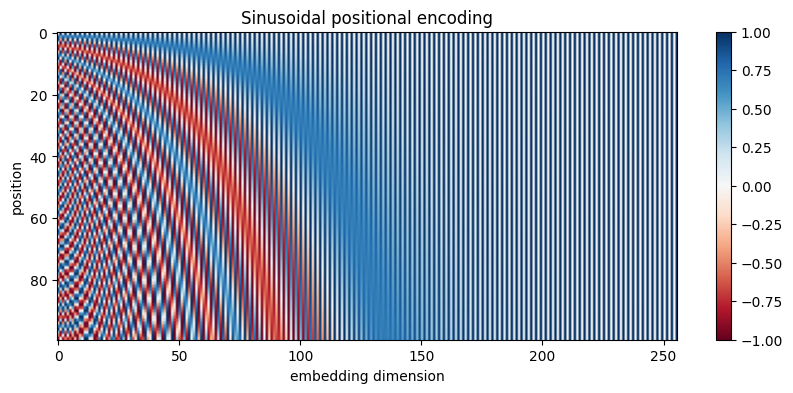

In [13]:
import sys; sys.path.insert(0, "starter")
import matplotlib.pyplot as plt
from embeddings import PositionalEncoding
pe = PositionalEncoding(256).pe[0, :100, :256]
plt.figure(figsize=(10, 4))
plt.imshow(pe.numpy(), aspect="auto", cmap="RdBu")
plt.xlabel("embedding dimension"); plt.ylabel("position"); plt.colorbar()
plt.title("Sinusoidal positional encoding")
plt.savefig("results/fig1_positional_encoding.png", dpi=150, bbox_inches="tight")

In [14]:
import json, os
import numpy as np
import sentencepiece as spm
from tokenizer import read_pairs

os.makedirs("results", exist_ok=True)
sp = spm.SentencePieceProcessor(model_file="starter/sql_sp.model")

MAX_SRC, MAX_TGT = 160, 64          # same limits the starter's SQLDataset uses
stats = {}
for split in ["train", "dev", "test"]:
    pairs = read_pairs(f"starter/{split}_pairs.jsonl")
    src_len = [len(sp.encode(p["src"])) + 1 for p in pairs]    # +1 for </s>
    tgt_len = [len(sp.encode(p["tgt"])) + 2 for p in pairs]    # +2 for <s> and </s>
    too_long = sum(1 for s, t in zip(src_len, tgt_len) if s > MAX_SRC or t > MAX_TGT)
    stats[split] = {
        "pairs": len(pairs),
        "src_mean": float(np.mean(src_len)), "src_max": int(np.max(src_len)),
        "tgt_mean": float(np.mean(tgt_len)), "tgt_max": int(np.max(tgt_len)),
        # only the training set drops long pairs; dev/test keep every row
        "dropped": too_long if split == "train" else "–",
    }

def cell(split, key, fmt="{}"):
    return fmt.format(stats[split][key])

table1 = f"""| | Train | Dev | Test |
|---|---|---|---|
| Pairs | {cell('train','pairs')} | {cell('dev','pairs')} | {cell('test','pairs')} |
| Mean / max source length (tokens) | {stats['train']['src_mean']:.1f} / {stats['train']['src_max']} | {stats['dev']['src_mean']:.1f} / {stats['dev']['src_max']} | {stats['test']['src_mean']:.1f} / {stats['test']['src_max']} |
| Mean / max target length (tokens) | {stats['train']['tgt_mean']:.1f} / {stats['train']['tgt_max']} | {stats['dev']['tgt_mean']:.1f} / {stats['dev']['tgt_max']} | {stats['test']['tgt_mean']:.1f} / {stats['test']['tgt_max']} |
| Pairs dropped as too long | {stats['train']['dropped']} | – | – |
"""
print(table1)
open("results/table1_data.md", "w").write(table1)
json.dump(stats, open("results/table1_data.json", "w"), indent=2)

| | Train | Dev | Test |
|---|---|---|---|
| Pairs | 56355 | 8421 | 15878 |
| Mean / max source length (tokens) | 42.5 / 222 | 42.5 / 167 | 42.7 / 260 |
| Mean / max target length (tokens) | 14.8 / 65 | 14.8 / 44 | 14.9 / 46 |
| Pairs dropped as too long | 19 | – | – |



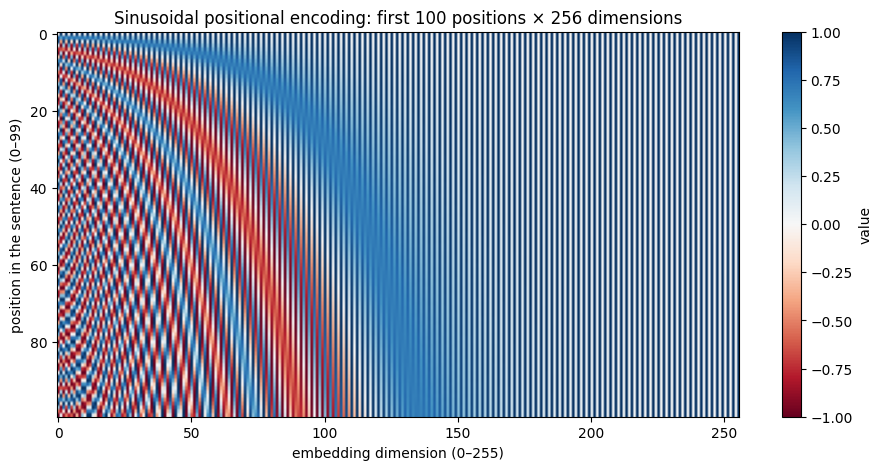

(100, 256)


In [15]:
import matplotlib.pyplot as plt
from embeddings import PositionalEncoding

pe = PositionalEncoding(d_model=256, max_len=512).pe[0, :100, :].numpy()   # (100 positions, 256 dims)

plt.figure(figsize=(11, 5))
plt.imshow(pe, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
plt.colorbar(label="value")
plt.xlabel("embedding dimension (0–255)")
plt.ylabel("position in the sentence (0–99)")
plt.title("Sinusoidal positional encoding: first 100 positions × 256 dimensions")
plt.savefig("results/fig1_positional_encoding.png", dpi=150, bbox_inches="tight")
plt.show()
print(pe.shape)

In [16]:
import math
import torch
import torch.nn as nn
def scaled_dot_product_attention(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(~mask, -1e9)
    weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(weights, v)
    return output, weights
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=256, h=4):
        super().__init__()
        assert d_model % h == 0, "d_model must be divisible by the number of heads"
        self.h = h
        self.d_k = d_model // h
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
    def _split_heads(self, x):
        batch, length, _ = x.shape
        x = x.view(batch, length, self.h, self.d_k)
        return x.transpose(1, 2)
    def forward(self, query, key, value, mask=None):
        batch = query.size(0)
        q = self._split_heads(self.w_q(query))
        k = self._split_heads(self.w_k(key))
        v = self._split_heads(self.w_v(value))
        out, weights = scaled_dot_product_attention(q, k, v, mask)
        out = out.transpose(1, 2).contiguous().view(batch, -1, self.h * self.d_k)
        return self.w_o(out), weights

In [17]:
import torch.nn as nn
from model.attention import MultiHeadAttention
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model=256, d_ff=1024):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.w2(self.relu(self.w1(x)))
class EncoderLayer(nn.Module):
    def __init__(self, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h)
        self.ffn = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, src_mask):
        attn_out, _ = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.drop(attn_out))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x
class DecoderLayer(nn.Module):
    def __init__(self, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h)
        self.cross_attn = MultiHeadAttention(d_model, h)
        self.ffn = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.cross_attn_weights = None
    def forward(self, x, memory, tgt_mask, src_mask):
        attn_out, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.drop(attn_out))
        cross_out, cross_w = self.cross_attn(x, memory, memory, src_mask)
        self.cross_attn_weights = cross_w.detach()
        x = self.norm2(x + self.drop(cross_out))
        x = self.norm3(x + self.drop(self.ffn(x)))
        return x
class Encoder(nn.Module):
    def __init__(self, n_layers=3, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, h, d_ff, dropout) for _ in range(n_layers)]
        )
    def forward(self, x, src_mask):
        for layer in self.layers:
            x = layer(x, src_mask)
        return x
class Decoder(nn.Module):
    def __init__(self, n_layers=3, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, h, d_ff, dropout) for _ in range(n_layers)]
        )
    def forward(self, x, memory, tgt_mask, src_mask):
        for layer in self.layers:
            x = layer(x, memory, tgt_mask, src_mask)
        return x

In [18]:
import torch.nn as nn
from model.attention import MultiHeadAttention
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model=256, d_ff=1024):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.w2(self.relu(self.w1(x)))
class EncoderLayer(nn.Module):
    def __init__(self, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h)
        self.ffn = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, src_mask):
        attn_out, _ = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.drop(attn_out))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x
class DecoderLayer(nn.Module):
    def __init__(self, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, h)
        self.cross_attn = MultiHeadAttention(d_model, h)
        self.ffn = PositionwiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.cross_attn_weights = None
    def forward(self, x, memory, tgt_mask, src_mask):
        attn_out, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.drop(attn_out))
        cross_out, cross_w = self.cross_attn(x, memory, memory, src_mask)
        self.cross_attn_weights = cross_w.detach()
        x = self.norm2(x + self.drop(cross_out))
        x = self.norm3(x + self.drop(self.ffn(x)))
        return x
class Encoder(nn.Module):
    def __init__(self, n_layers=3, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderLayer(d_model, h, d_ff, dropout) for _ in range(n_layers)]
        )
    def forward(self, x, src_mask):
        for layer in self.layers:
            x = layer(x, src_mask)
        return x
class Decoder(nn.Module):
    def __init__(self, n_layers=3, d_model=256, h=4, d_ff=1024, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [DecoderLayer(d_model, h, d_ff, dropout) for _ in range(n_layers)]
        )
    def forward(self, x, memory, tgt_mask, src_mask):
        for layer in self.layers:
            x = layer(x, memory, tgt_mask, src_mask)
        return x

In [20]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
sys.path.insert(0, r"D:\Downloads\Text-to-SQL-Transformers\starter")
from embeddings import TokenEmbedding, InputLayer
from model.layers import Encoder, Decoder

def make_pad_mask(ids, pad_id=0):
    return (ids != pad_id).unsqueeze(1).unsqueeze(2)

def make_causal_mask(length, device=None):
    return torch.tril(torch.ones(length, length, dtype=torch.bool, device=device)).unsqueeze(0).unsqueeze(0)

def make_tgt_mask(tgt_ids, pad_id=0):
    pad = make_pad_mask(tgt_ids, pad_id)
    causal = make_causal_mask(tgt_ids.size(1), tgt_ids.device)
    return pad & causal

class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, h=4, n_layers=3, d_ff=1024,
                 dropout=0.1, pad_id=0):
        super().__init__()
        self.pad_id = pad_id
        shared = TokenEmbedding(vocab_size, d_model, pad_id)
        self.src_in = InputLayer(shared, d_model, dropout=dropout)
        self.tgt_in = InputLayer(shared, d_model, dropout=dropout)
        self.encoder = Encoder(n_layers, d_model, h, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, h, d_ff, dropout)
        self.out_proj = nn.Linear(d_model, vocab_size, bias=False)
        self.out_proj.weight = shared.emb.weight
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        with torch.no_grad():
            self.src_in.tok.emb.weight[self.pad_id].zero_()

    def encode(self, src):
        src_mask = make_pad_mask(src, self.pad_id)
        memory = self.encoder(self.src_in(src), src_mask)
        return memory, src_mask

    def decode(self, tgt_in, memory, src_mask):
        tgt_mask = make_tgt_mask(tgt_in, self.pad_id)
        hidden = self.decoder(self.tgt_in(tgt_in), memory, tgt_mask, src_mask)
        return self.out_proj(hidden)


    def forward(self, src, tgt_in):
        memory, src_mask = self.encode(src)
        return self.decode(tgt_in, memory, src_mask)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [21]:
import importlib, sys
import sentencepiece as spm
import torch
sys.path.insert(0, "starter")
import model.attention, model.layers, model.transformer

for m in (model.attention, model.layers, model.transformer):
    importlib.reload(m)

from model.transformer import Transformer, count_parameters

sp = spm.SentencePieceProcessor(model_file="starter/sql_sp.model")
V = sp.get_piece_size()
net = Transformer(vocab_size=V)
n_params = count_parameters(net)
print("vocab size          :", V)
print("trainable parameters:", f"{n_params:,}")

vocab size          : 8000
trainable parameters: 7,577,600


In [36]:
import torch
from model.attention import scaled_dot_product_attention
torch.manual_seed(0)
net.eval()

src = torch.randint(4, V, (2, 10))
tgt = torch.randint(4, V, (2, 8))


normal_output = net(src, tgt)

changed_tgt = tgt.clone()
changed_tgt[:, -1] = (tgt[:, -1] - 4 + 1) % (V - 4) + 4

changed_output = net(src, changed_tgt)

earlier_same = torch.allclose(
    normal_output[:, :-1],
    changed_output[:, :-1],
    atol=1e-5
)

last_changed = not torch.allclose(
    normal_output[:, -1],
    changed_output[:, -1],
    atol=1e-5
)

print(
    f"[1] Causal mask: earlier outputs unchanged = {earlier_same} | "
    f"last output changed = {last_changed}"
)

src_padded = torch.cat(
    [src, torch.zeros(2, 6, dtype=torch.long)],
    dim=1
)
padded_output = net(src_padded, tgt)
padding_works = torch.allclose(
    normal_output,
    padded_output,
    atol=1e-5
)
print(
    f"[2] Padding mask: output unchanged after adding <pad> "
    f"= {padding_works}"
)

q = torch.randn(2, 4, 5, 64)
k = torch.randn(2, 4, 7, 64)
v = torch.randn(2, 4, 7, 64)
mask = torch.zeros(2, 1, 1, 7, dtype=torch.bool)
mask[0, :, :, :7] = True
mask[1, :, :, :4] = True

_, attention_weights = scaled_dot_product_attention(
    q, k, v, mask
)
rows_sum_to_one = torch.allclose(
    attention_weights.sum(-1),
    torch.ones_like(attention_weights.sum(-1)),
    atol=1e-5
)
masked_zero = (
    attention_weights
    .masked_select(~mask.expand_as(attention_weights))
    .abs()
    .max()
    .item() < 1e-6
)
print(
    f"[3] Attention rows: every row sums to 1 = {rows_sum_to_one} | "
    f"masked positions get weight 0 = {masked_zero}"
)

net(src_padded, tgt)
cross_weights = net.decoder.layers[-1].cross_attn_weights
cross_rows_sum_to_one = torch.allclose(
    cross_weights.sum(-1),
    torch.ones_like(cross_weights.sum(-1)),
    atol=1e-5
)
padded_source_weight = cross_weights[..., 10:].abs().max().item()
print(
    f"    Real model: cross-attention rows sum to 1 = "
    f"{cross_rows_sum_to_one} | "
    f"weight on padded source positions = "
    f"{padded_source_weight:.1e}"
)

shared = (
    net.out_proj.weight is net.src_in.tok.emb.weight
    and
    net.out_proj.weight is net.tgt_in.tok.emb.weight
)
print(
    f"[4] Weight sharing: output projection and embedding are "
    f"the same tensor = {shared}"
)


import os

report = [
    f"[1] causal mask: earlier outputs unchanged = {earlier_same} | last output changed = {last_changed}",
    f"[2] padding mask: output unchanged after adding <pad> = {padding_works}",
    f"[3] attention rows: rows sum to 1 = {rows_sum_to_one} | masked positions have zero weight = {masked_zero}",
    f"real model: cross-attention rows sum to 1 = {cross_rows_sum_to_one} | padded source weight = {padded_source_weight:.1e}",
    f"[4] weight sharing: output projection and embeddings use the same tensor = {shared}"
]

os.makedirs("results", exist_ok=True)

with open("results/correctness_checks.txt", "w") as f:
    f.write("\n".join(report))

print("\n".join(report))
print("\nsaved to results/correctness_checks.txt")


[1] Causal mask: earlier outputs unchanged = True | last output changed = True
[2] Padding mask: output unchanged after adding <pad> = True
[3] Attention rows: every row sums to 1 = True | masked positions get weight 0 = True
    Real model: cross-attention rows sum to 1 = True | weight on padded source positions = 0.0e+00
[4] Weight sharing: output projection and embedding are the same tensor = True
[1] causal mask: earlier outputs unchanged = True | last output changed = True
[2] padding mask: output unchanged after adding <pad> = True
[3] attention rows: rows sum to 1 = True | masked positions have zero weight = True
real model: cross-attention rows sum to 1 = True | padded source weight = 0.0e+00
[4] weight sharing: output projection and embeddings use the same tensor = True

saved to results/correctness_checks.txt


In [26]:
import argparse
import json
import sys
import time
from pathlib import Path
import torch.nn as nn


ROOT = Path("/content/Text-to-SQL-Transformers")
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "starter"))

from dataset import make_loader
from tokenizer import PAD_ID
from model.transformer import Transformer, count_parameters


CONFIG = {
    "d_model": 256,
    "h": 4,
    "n_layers": 3,
    "d_ff": 1024,
    "dropout": 0.1
}

WARMUP = 4000
LABEL_SMOOTHING = 0.1


def noam_lr(step):
    step = max(step, 1)
    return CONFIG["d_model"] ** -0.5 * min(
        step ** -0.5,
        step * WARMUP ** -1.5
    )


def run_epoch(model, loader, criterion, device, optimizer=None, scheduler=None):
    training = optimizer is not None
    model.train(training)

    total_loss = 0
    total_tokens = 0

    for src, tgt in loader:
        src = src.to(device)
        tgt = tgt.to(device)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        with torch.set_grad_enabled(training):
            logits = model(src, tgt_input)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_output.reshape(-1)
            )

        if training:
            optimizer.zero_grad(),loss.backward(),optimizer.step(),scheduler.step()

        tokens = (tgt_output != PAD_ID).sum().item()

        total_loss += loss.item() * tokens
        total_tokens += tokens
    return total_loss / total_tokens


def main():

    parser = argparse.ArgumentParser()

    parser.add_argument("--epochs", type=int, default=20)
    parser.add_argument("--batch_size", type=int, default=64)
    parser.add_argument("--ckpt_dir", default="checkpoints")
    parser.add_argument("--results_dir", default="results")
    parser.add_argument("--resume", action="store_true")

    args = parser.parse_args(args=[])

    torch.manual_seed(42)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    ckpt_dir = Path(args.ckpt_dir)
    results_dir = Path(args.results_dir)

    ckpt_dir.mkdir(exist_ok=True)
    results_dir.mkdir(exist_ok=True)

    sp = spm.SentencePieceProcessor(
        model_file=str(ROOT / "starter" / "sql_sp.model")
    )

    vocab_size = sp.get_piece_size()

    train_loader = make_loader(
        str(ROOT / "starter" / "train_pairs.jsonl"),sp,train=True,batch_size=args.batch_size)

    dev_loader = make_loader(str(ROOT / "starter" / "dev_pairs.jsonl"),sp,train=False,batch_size=args.batch_size)

    model = Transformer(vocab_size,**CONFIG).to(device)

    print( f"Device: {device}" f"\nTrainable parameters: {count_parameters(model):,}")

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID,label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.Adam( model.parameters(),lr=1.0,betas=(0.9, 0.98),eps=1e-9 )
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer,lr_lambda=lambda step: noam_lr(step + 1))

    history = []
    best_dev_loss = float("inf")
    best_epoch = 0
    start_epoch = 1

    last_checkpoint = ckpt_dir / "last.pt"

    if args.resume and last_checkpoint.exists():

        checkpoint = torch.load( last_checkpoint, map_location=device)

        model.load_state_dict(checkpoint["model"])
        optimizer.load_state_dict(checkpoint["optimizer"])
        scheduler.load_state_dict(checkpoint["scheduler"])

        history = checkpoint["history"]
        best_dev_loss = checkpoint["best_dev"]
        best_epoch = checkpoint["best_epoch"]
        start_epoch = checkpoint["epoch"] + 1

        print(f"Resumed from epoch {checkpoint['epoch']}")

    start_time = time.time()

    for epoch in range(start_epoch, args.epochs + 1):
        train_loss = run_epoch(model,train_loader,criterion,device,optimizer,scheduler)
        dev_loss = run_epoch(model,dev_loader,criterion,device)
        learning_rate = optimizer.param_groups[0]["lr"]

        history.append({ "epoch": epoch,"train_loss": train_loss,"dev_loss": dev_loss,"lr": learning_rate})

        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            best_epoch = epoch
            torch.save({"model": model.state_dict(),"config": CONFIG,"vocab_size": vocab_size,"epoch": epoch,"dev_loss": dev_loss},
                ckpt_dir / "best.pt"
            )
            best = " <- best"
        else:
            best = ""
        torch.save({"model": model.state_dict(),"optimizer": optimizer.state_dict(),"scheduler": scheduler.state_dict(),
                "history": history,"best_dev": best_dev_loss, "best_epoch": best_epoch, "epoch": epoch},last_checkpoint)

        (results_dir / "history.json").write_text(
            json.dumps(history, indent=2)
        )
        print( f"Epoch {epoch:2d}/{args.epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Dev loss: {dev_loss:.4f} | "
            f"LR: {learning_rate:.6f}{best}"
        )

    training_time = (time.time() - start_time) / 60
    training_info = {
        "epochs_trained": len(history),
        "best_epoch": best_epoch,
        "best_dev_loss": best_dev_loss,
        "training_time_min": training_time,
        "trainable_parameters": count_parameters(model),
        "device": torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU"
    }

    (results_dir / "training_info.json").write_text(
        json.dumps(training_info, indent=2)
    )

    print("\nTraining complete.")
    print(training_info)
if __name__ == "__main__":
    main()

/content/Text-to-SQL-Transformers/starter/train_pairs.jsonl: kept 56336, skipped 19
/content/Text-to-SQL-Transformers/starter/dev_pairs.jsonl: kept 8421, skipped 0
Device: cuda
Trainable parameters: 7,577,600
Epoch  1/20 | Train loss: 4.9666 | Dev loss: 3.4736 | LR: 0.000218 <- best
Epoch  2/20 | Train loss: 3.1806 | Dev loss: 2.7148 | LR: 0.000436 <- best
Epoch  3/20 | Train loss: 2.4032 | Dev loss: 2.0026 | LR: 0.000653 <- best
Epoch  4/20 | Train loss: 1.9600 | Dev loss: 1.8533 | LR: 0.000871 <- best
Epoch  5/20 | Train loss: 1.8456 | Dev loss: 1.7574 | LR: 0.000942 <- best
Epoch  6/20 | Train loss: 1.7063 | Dev loss: 1.6580 | LR: 0.000860 <- best
Epoch  7/20 | Train loss: 1.6070 | Dev loss: 1.5766 | LR: 0.000796 <- best
Epoch  8/20 | Train loss: 1.5475 | Dev loss: 1.5383 | LR: 0.000744 <- best
Epoch  9/20 | Train loss: 1.5085 | Dev loss: 1.5327 | LR: 0.000702 <- best
Epoch 10/20 | Train loss: 1.4803 | Dev loss: 1.4966 | LR: 0.000666 <- best
Epoch 11/20 | Train loss: 1.4591 | Dev lo

In [1]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0))
!pip install -q sentencepiece records babel tqdm tabulate

True Tesla T4
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00


In [2]:
%cd /content
!git clone https://github.com/musfiraumar/Text-to-SQL-Transformers.git
%cd /content/Text-to-SQL-Transformers

/content
Cloning into 'Text-to-SQL-Transformers'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 92 (delta 12), reused 86 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (92/92), 26.22 MiB | 21.83 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/Text-to-SQL-Transformers


In [3]:
%cd WikiSQL
!tar xjf data.tar.bz2
%cd ..
!ln -sfn ../WikiSQL starter/WikiSQL
!mkdir -p results checkpoints
!touch model/__init__.py

/content/Text-to-SQL-Transformers/WikiSQL
/content/Text-to-SQL-Transformers


In [4]:
%cd starter
!python data_prep.py
%cd ..

/content/Text-to-SQL-Transformers/starter
train: 56355 pairs
dev: 8421 pairs
test: 15878 pairs
what is terrence ross' nationality <sep> <c0> player <c1> no. <c2> nationality <c3> position <c4> years in toronto <c5> school/club team
select <c2> where <c0> = terrence ross
/content/Text-to-SQL-Transformers


In [5]:
!python train.py --epochs 1 --max_batches 20 --ckpt_dir /tmp/smoke_ckpt --results_dir /tmp/smoke_results

usage: train.py [-h] [--epochs EPOCHS] [--batch_size BATCH_SIZE]
                [--ckpt_dir CKPT_DIR] [--results_dir RESULTS_DIR] [--resume]
train.py: error: unrecognized arguments: --max_batches 20


In [27]:
from google.colab import drive
drive.mount("/content/drive")
!mkdir -p /content/drive/MyDrive/genai_a2/checkpoints
!rm -rf checkpoints
!ln -s /content/drive/MyDrive/genai_a2/checkpoints checkpoints

Mounted at /content/drive


In [28]:
from google.colab import drive
drive.mount("/content/drive")
!mkdir -p /content/drive/MyDrive/genai_a2/checkpoints
!python train.py --epochs 20 --batch_size 64 --ckpt_dir /content/drive/MyDrive/genai_a2/checkpoints

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/Text-to-SQL-Transformers/starter/train_pairs.jsonl: kept 56336, skipped 19
/content/Text-to-SQL-Transformers/starter/dev_pairs.jsonl: kept 8421, skipped 0
Device: cuda
Trainable parameters: 7,577,600
Epoch  1/20 | Train loss: 4.9666 | Dev loss: 3.4736 | LR: 0.000218 <- best
Epoch  2/20 | Train loss: 3.1806 | Dev loss: 2.7148 | LR: 0.000436 <- best
Epoch  3/20 | Train loss: 2.4032 | Dev loss: 2.0026 | LR: 0.000653 <- best
Epoch  4/20 | Train loss: 1.9600 | Dev loss: 1.8533 | LR: 0.000871 <- best
Epoch  5/20 | Train loss: 1.8456 | Dev loss: 1.7574 | LR: 0.000942 <- best
Epoch  6/20 | Train loss: 1.7063 | Dev loss: 1.6580 | LR: 0.000860 <- best
Epoch  7/20 | Train loss: 1.6070 | Dev loss: 1.5766 | LR: 0.000796 <- best
Epoch  8/20 | Train loss: 1.5475 | Dev loss: 1.5383 | LR: 0.000744 <- best
Epoch  9/20 | Train loss: 1.5085 | Dev loss: 1.5327 | LR: 0.00

In [29]:
!mkdir -p checkpoints
!cp /content/drive/MyDrive/genai_a2/checkpoints/best.pt checkpoints/best.pt
from google.colab import files
files.download("checkpoints/best.pt")      # copy on your own laptop too
files.download("results/history.json")
files.download("results/training_info.json")

cp: '/content/drive/MyDrive/genai_a2/checkpoints/best.pt' and 'checkpoints/best.pt' are the same file


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

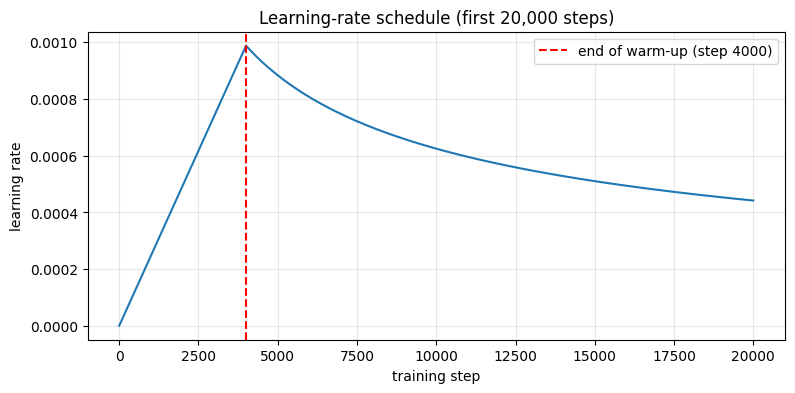

peak lr at step 4000                = 0.000988  (expected 256^-0.5 * 4000^-0.5 = 0.000988)
lr(2000) / lr(4000)                 = 0.500  (linear rise -> 0.500)
lr(16000) / lr(4000)                = 0.500  (step^-0.5 decay: sqrt(4000/16000) -> 0.500)


277

In [30]:
import importlib, matplotlib.pyplot as plt
import train
importlib.reload(train)
from train import noam_lr

steps = list(range(1, 20001))
lrs = [noam_lr(s) for s in steps]

plt.figure(figsize=(9, 4))
plt.plot(steps, lrs)
plt.axvline(4000, color="red", linestyle="--", label="end of warm-up (step 4000)")
plt.xlabel("training step"); plt.ylabel("learning rate")
plt.title("Learning-rate schedule (first 20,000 steps)")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("results/fig3_lr_schedule.png", dpi=150, bbox_inches="tight")
plt.show()

peak = noam_lr(4000)
lines = [
    f"peak lr at step 4000                = {peak:.6f}  (expected 256^-0.5 * 4000^-0.5 = {256**-0.5 * 4000**-0.5:.6f})",
    f"lr(2000) / lr(4000)                 = {noam_lr(2000)/peak:.3f}  (linear rise -> 0.500)",
    f"lr(16000) / lr(4000)                = {noam_lr(16000)/peak:.3f}  (step^-0.5 decay: sqrt(4000/16000) -> 0.500)",
]
print("\n".join(lines))
open("results/correctness_checks.txt", "a").write("\n[5] Learning-rate schedule\n" + "\n".join(lines) + "\n")

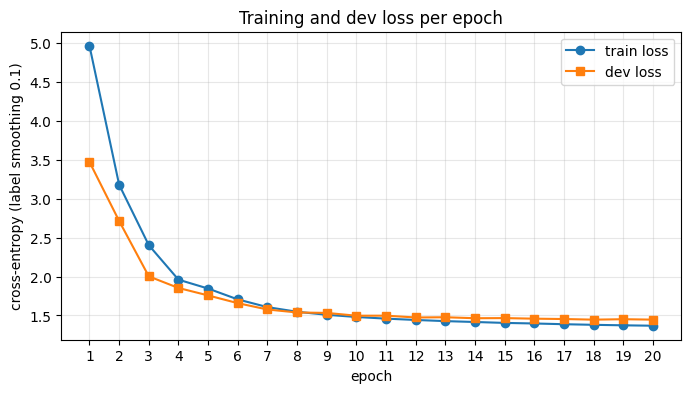

| | |
|---|---|
| Trainable parameters | 7,577,600 |
| Epochs trained / best epoch | 20 / 18 |
| Best dev loss | 1.4459 |
| Training time and GPU | 21.8 min on Tesla T4 |



171

In [33]:
import json
import matplotlib.pyplot as plt

history = json.load(open("results/history.json"))
epochs = [h["epoch"] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(epochs, [h["train_loss"] for h in history], marker="o", label="train loss")
plt.plot(epochs, [h["dev_loss"] for h in history], marker="s", label="dev loss")
plt.xlabel("epoch"); plt.ylabel("cross-entropy (label smoothing 0.1)")
plt.title("Training and dev loss per epoch"); plt.xticks(epochs); plt.legend(); plt.grid(alpha=0.3)
plt.savefig("results/fig2_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

info = json.load(open("results/training_info.json"))

table2 = f"""| | |
|---|---|
| Trainable parameters | {info['trainable_parameters']:,} |
| Epochs trained / best epoch | {info['epochs_trained']} / {info['best_epoch']} |
| Best dev loss | {info['best_dev_loss']:.4f} |
| Training time and GPU | {info['training_time_min']:.1f} min on {info['device']} |
"""

print(table2)

open("results/table2_model_training.md", "w").write(table2)





In [34]:
import json

info = json.load(open("results/training_info.json"))

print(info)
print("\nAvailable keys:")
print(info.keys())

{'epochs_trained': 20, 'best_epoch': 18, 'best_dev_loss': 1.4459493619281403, 'training_time_min': 21.8360555489858, 'trainable_parameters': 7577600, 'device': 'Tesla T4'}

Available keys:
dict_keys(['epochs_trained', 'best_epoch', 'best_dev_loss', 'training_time_min', 'trainable_parameters', 'device'])


In [39]:

import json
import re
import sys
from pathlib import Path
import torch
ROOT = Path("/content/Text-to-SQL-Transformers")
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "starter"))
from data_prep import AGG_OPS, COND_OPS
from tokenizer import PAD_ID, BOS_ID, EOS_ID
from model.transformer import Transformer
MAX_LEN = 64
def load_model(ckpt_path, device="cpu"):
    checkpoint = torch.load(ckpt_path, map_location=device)
    model = Transformer(checkpoint["vocab_size"], **checkpoint["config"]).to(device)
    model.load_state_dict(checkpoint["model"])
    model.eval()
    return model, checkpoint
def trim_ids(ids):
    out = []
    for token_id in ids:
        if token_id in (EOS_ID, PAD_ID):
            break
        if token_id == BOS_ID:
            continue
        out.append(token_id)
    return out
@torch.no_grad()
def greedy_decode(model, src, max_len=MAX_LEN):
    model.eval()
    memory, src_mask = model.encode(src)
    batch = src.size(0)
    ys = torch.full((batch, 1), BOS_ID, dtype=torch.long, device=src.device)
    finished = torch.zeros(batch, dtype=torch.bool, device=src.device)
    for _ in range(max_len):
        logits = model.decode(ys, memory, src_mask)
        next_tok = logits[:, -1].argmax(dim=-1)
        next_tok = next_tok.masked_fill(finished, PAD_ID)
        ys = torch.cat([ys, next_tok.unsqueeze(1)], dim=1)
        finished = finished | (next_tok == EOS_ID)
        if finished.all():
            break
    return [trim_ids(row.tolist()) for row in ys]
@torch.no_grad()
def beam_search(model, src, beam_size=4, max_len=MAX_LEN):
    model.eval()
    memory, src_mask = model.encode(src)
    beams = [([BOS_ID], 0.0)]
    finished = []
    for _ in range(max_len):
        ys = torch.tensor([seq for seq, _ in beams], dtype=torch.long, device=src.device)
        n_beams = ys.size(0)
        logits = model.decode(ys, memory.expand(n_beams, -1, -1), src_mask.expand(n_beams, -1, -1, -1))
        log_probs = torch.log_softmax(logits[:, -1], dim=-1)
        top_lp, top_id = log_probs.topk(beam_size, dim=-1)
        candidates = []
        for i, (seq, score) in enumerate(beams):
            for log_prob, token in zip(top_lp[i].tolist(), top_id[i].tolist()):
                candidates.append((seq + [token], score + log_prob))
        candidates.sort(key=lambda c: c[1], reverse=True)
        beams = []
        for seq, score in candidates:
            if seq[-1] == EOS_ID:
                finished.append((seq, score / len(seq)))
            else:
                beams.append((seq, score))
            if len(beams) == beam_size:
                break
        if len(finished) >= beam_size or not beams:
            break
    if not finished:
        finished = [(seq, score / len(seq)) for seq, score in beams]
    best_seq = max(finished, key=lambda c: c[1])[0]
    return trim_ids(best_seq)
def translate(model, sp, loader, method="greedy", device="cpu", beam_size=4, max_items=0):
    from tqdm import tqdm
    texts = []
    for src, _ in tqdm(loader, desc=f"decoding ({method})"):
        src = src.to(device)
        if method == "greedy":
            id_lists = greedy_decode(model, src)
        else:
            id_lists = []
            for i in range(src.size(0)):
                n = int((src[i] != PAD_ID).sum())
                id_lists.append(beam_search(model, src[i:i + 1, :n], beam_size))
        texts.extend(sp.decode(ids) for ids in id_lists)
        if max_items and len(texts) >= max_items:
            break
    return texts[:max_items] if max_items else texts
_AGG_WORDS = [a.lower() for a in AGG_OPS]
_SELECT_RE = re.compile(r"^select\s+(?:(max|min|count|sum|avg)\s+)?<c(\d+)>\s*(.*)$", re.DOTALL)
_WHERE_RE = re.compile(r"^where\s+(.*)$", re.DOTALL)
_SPLIT_RE = re.compile(r"\s+and\s+(?=<c\d+>\s*[=<>])")
_COND_RE = re.compile(r"^<c(\d+)>\s*([=<>])\s*(.*)$", re.DOTALL)
def parse_target(text):
    text = text.strip()
    select_match = _SELECT_RE.match(text)
    if not select_match:
        return None
    agg_word, sel, rest = select_match.group(1), int(select_match.group(2)), select_match.group(3).strip()
    agg = _AGG_WORDS.index(agg_word) if agg_word else 0
    conds = []
    if rest:
        where_match = _WHERE_RE.match(rest)
        if not where_match:
            return None
        for part in _SPLIT_RE.split(where_match.group(1)):
            c = _COND_RE.match(part.strip())
            if not c:
                return None
            conds.append([int(c.group(1)), COND_OPS.index(c.group(2)), c.group(3).strip()])
    return {"sel": sel, "agg": agg, "conds": conds}
def to_prediction_line(text):
    query = parse_target(text)
    return {"query": query} if query is not None else {"error": "parse"}
def write_prediction_file(texts, path):
    n_errors = 0
    with open(path, "w", encoding="utf-8") as f:
        for text in texts:
            line = to_prediction_line(text)
            n_errors += "error" in line
            f.write(json.dumps(line) + "\n")
    return n_errors
def _is_number(s):
    try:
        float(s)
        return True
    except ValueError:
        return False
def query_to_sql(query, header, table="table"):
    def col(i):
        return header[i] if 0 <= i < len(header) else f"<invalid column {i}>"
    select = col(query["sel"])
    if query["agg"]:
        select = f"{AGG_OPS[query['agg']]}({select})"
    sql = f"SELECT {select} FROM {table}"
    if query["conds"]:
        parts = []
        for c, op, value in query["conds"]:
            value = str(value)
            shown = value if (op in (1, 2) and _is_number(value)) else f"'{value}'"
            parts.append(f"{col(c)} {COND_OPS[op]} {shown}")
        sql += " WHERE " + " AND ".join(parts)
    return sql

In [40]:
import importlib
import decode
importlib.reload(decode)
from decode import parse_target, query_to_sql, to_prediction_line
header = ["Player", "No.", "Nationality", "Position", "Years in Toronto", "School/Club Team"]
text = "select <c2> where <c0> = terrence ross"
q = parse_target(text)
print(q)
print(query_to_sql(q, header))
print(parse_target("select count <c3> where <c1> = kim manners and <c4> > 5"))
print(parse_target("select <c0> where <c1> = tom and jerry"))
print(to_prediction_line("this is nonsense"))

{'sel': 2, 'agg': 0, 'conds': [[0, 0, 'terrence ross']]}
SELECT Nationality FROM table WHERE Player = 'terrence ross'
{'sel': 3, 'agg': 3, 'conds': [[1, 0, 'kim manners'], [4, 1, '5']]}
{'sel': 0, 'agg': 0, 'conds': [[1, 0, 'tom and jerry']]}
{'error': 'parse'}


In [ ]:
import sentencepiece as spm
from tokenizer import read_pairs
from decode import write_prediction_file

sp = spm.SentencePieceProcessor(model_file="starter/sql_sp.model")
dev_pairs = read_pairs("starter/dev_pairs.jsonl")

gold_texts = [p["tgt"] for p in dev_pairs]
n_err = write_prediction_file(gold_texts, "results/dev_gold_roundtrip.jsonl")
print("parse failures on gold text:", n_err)

via_tok = [sp.decode(sp.encode(t)) for t in gold_texts]
n_err2 = write_prediction_file(via_tok, "results/dev_gold_roundtrip_tokenizer.jsonl")
print("parse failures after tokenizer round-trip:", n_err2)

In [ ]:
!cd WikiSQL && python evaluate.py data/dev.jsonl data/dev.db ../results/dev_gold_roundtrip.jsonl 2>&1 | tee ../results/official_dev_gold_roundtrip.txt
!cd WikiSQL && python evaluate.py data/dev.jsonl data/dev.db ../results/dev_gold_roundtrip_tokenizer.jsonl 2>&1 | tee ../results/official_dev_gold_roundtrip_tokenizer.txt

In [ ]:
import argparse
import json
import os
import random
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import sentencepiece as spm
import torch

ROOT = Path(__file__).resolve().parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "starter"))

from data_prep import load_split
from dataset import make_loader
from tokenizer import read_pairs, BOS_ID, EOS_ID
from decode import (
    load_model,
    translate,
    greedy_decode,
    parse_target,
    write_prediction_file,
    query_to_sql
)

def where_set(conditions):
    return {
        (int(col), int(op), str(value).strip().lower())
        for col, op, value in conditions
    }

def component_accuracy(predictions, examples):
    total = len(examples)
    select_correct = 0
    agg_correct = 0
    where_correct = 0

    for prediction, example in zip(predictions, examples):
        pred = parse_target(prediction)

        if pred is None:
            continue

        gold = example["sql"]

        if pred["sel"] == gold["sel"]:
            select_correct += 1

        if pred["agg"] == gold["agg"]:
            agg_correct += 1

        if where_set(pred["conds"]) == where_set(gold["conds"]):
            where_correct += 1

    return {
        "sel_acc": 100 * select_correct / total,
        "agg_acc": 100 * agg_correct / total,
        "where_acc": 100 * where_correct / total
    }

def classify_failure(gold, prediction):
    if prediction is None:
        return "parse failure"
    reasons = []

    if prediction["sel"] != gold["sel"]:
        reasons.append("wrong select column")

    if prediction["agg"] != gold["agg"]:
        reasons.append("wrong aggregation")

    gold_conditions = where_set(gold["conds"])
    pred_conditions = where_set(prediction["conds"])

    if gold_conditions != pred_conditions:
        if len(pred_conditions) < len(gold_conditions):
            reasons.append("missing condition")

        elif len(pred_conditions) > len(gold_conditions):
            reasons.append("extra condition")

        elif {(c, o) for c, o, _ in gold_conditions} == {
            (c, o) for c, o, _ in pred_conditions
        }:
            reasons.append("wrong value")

        else:
            reasons.append("wrong condition column/operator")

    return ", ".join(reasons)

def make_samples(predictions, examples, tables, output_path, n_each=5, seed=0):
    correct = []
    wrong = []

    for i, (prediction, example) in enumerate(zip(predictions, examples)):
        pred = parse_target(prediction)

        if classify_failure(example["sql"], pred):
            wrong.append(i)
        else:
            correct.append(i)

    random.seed(seed)

    correct_picks = random.sample(correct, min(n_each, len(correct)))
    wrong_picks = random.sample(wrong, min(n_each, len(wrong)))

    selected = (
        [("CORRECT", i) for i in correct_picks] +
        [("WRONG", i) for i in wrong_picks]
    )

    lines = ["# Qualitative samples (dev set)\n"]

    for number, (label, i) in enumerate(selected, 1):
        example = examples[i]
        header = tables[example["table_id"]]["header"]
        prediction = parse_target(predictions[i])

        if prediction:
            predicted_sql = query_to_sql(prediction, header)
        else:
            predicted_sql = f"(could not parse) {predictions[i]}"

        lines.append(f"## Example {number} - {label}  (dev line {i})")
        lines.append(f"- **Question:** {example['question']}")
        lines.append(
            f"- **Gold SQL:** `{query_to_sql(example['sql'], header)}`"
        )
        lines.append(f"- **Our SQL:** `{predicted_sql}`")

        if label == "WRONG":
            failure = classify_failure(example["sql"], prediction)
            lines.append(f"- **Failure:** {failure}")

        lines.append("")

    Path(output_path).write_text(
        "\n".join(lines),
        encoding="utf-8"
    )

def clean_piece(piece):
    return piece.replace("\u2581", "")
@torch.no_grad()

def plot_cross_attention(model, sp, source_text, device, output_png, output_txt):
    model.eval()
    source_ids = sp.encode(source_text) + [EOS_ID]
    source = torch.tensor([source_ids], device=device)

    generated = greedy_decode(model, source)[0]
    decoder_input = torch.tensor(
        [[BOS_ID] + generated],
        device=device
    )

    model(source, decoder_input)
    weights = model.decoder.layers[-1].cross_attn_weights[0]
    attention = weights.mean(dim=0).cpu().numpy()
    source_labels = [
        sp.id_to_piece(i)
        for i in source_ids
    ]

    target_labels = [
        sp.id_to_piece(i)
        for i in generated + [EOS_ID]
    ]

    fig, ax = plt.subplots(
        figsize=(
            max(9, 0.28 * len(source_labels)),
            max(4, 0.4 * len(target_labels))
        )
    )

    image = ax.imshow(
        attention,
        aspect="auto",
        cmap="viridis"
    )

    ax.set_xticks(range(len(source_labels)))
    ax.set_xticklabels(
        source_labels,
        rotation=90,
        fontsize=8
    )

    ax.set_yticks(range(len(target_labels)))
    ax.set_yticklabels(
        target_labels,
        fontsize=9
    )

    ax.set_xlabel("source tokens (question <sep> columns)")
    ax.set_ylabel("generated tokens")
    ax.set_title(
        "Decoder cross-attention, last layer, averaged over heads"
    )

    fig.colorbar(image, ax=ax)
    fig.savefig(
        output_png,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close(fig)
    column_markers = {
        i: clean_piece(label)
        for i, label in enumerate(source_labels)
        if re.fullmatch(r"<c\d+>", clean_piece(label))
    }

    column_positions = sorted(column_markers)
    report = [
        "generated text: " + sp.decode(generated),
        ""
    ]

    for row, label in enumerate(target_labels):
        name = clean_piece(label)

        if not re.fullmatch(r"<c\d+>", name):
            continue

        most_attended = int(attention[row].argmax())
        start = next(
            (
                position
                for position in column_positions
                if column_markers[position] == name
            ),
            None
        )

        if start is None:
            result = "that column does not exist in the source"
        else:
            end = next(
                (
                    position
                    for position in column_positions
                    if position > start
                ),
                len(source_labels) - 1
            )

            if start <= most_attended < end:
                result = "MATCH (inside the right column)"
            else:
                result = "no match"

        report.append(
            f"{name:>5} attends most to source token "
            f"{source_labels[most_attended]!r} "
            f"(weight {attention[row, most_attended]:.2f}) "
            f"-> {result}"
        )

    Path(output_txt).write_text(
        "\n".join(report),
        encoding="utf-8"
    )

    print("\n".join(report))
    
def main():
    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--split",
        default="dev",
        choices=["dev", "test"]
    )

    parser.add_argument(
        "--method",
        default="greedy",
        choices=["greedy", "beam"]
    )

    parser.add_argument(
        "--ckpt",
        default="checkpoints/best.pt"
    )

    parser.add_argument(
        "--beam_size",
        type=int,
        default=4
    )

    parser.add_argument(
        "--limit",
        type=int,
        default=0
    )

    parser.add_argument(
        "--attn_index",
        type=int,
        default=-1
    )

    parser.add_argument(
        "--results_dir",
        default="results"
    )

    args = parser.parse_args()

    os.chdir(ROOT)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    results_dir = Path(args.results_dir)
    results_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    sp = spm.SentencePieceProcessor(
        model_file="starter/sql_sp.model"
    )

    model, _ = load_model(
        args.ckpt,
        device
    )

    batch_size = 128 if args.method == "greedy" else 64

    loader = make_loader(
        f"starter/{args.split}_pairs.jsonl",
        sp,
        train=False,
        batch_size=batch_size
    )

    predictions = translate(
        model,
        sp,
        loader,
        args.method,
        device,
        args.beam_size,
        args.limit
    )

    tag = f"{args.split}_{args.method}"

    prediction_file = results_dir / f"{tag}.jsonl"

    parse_failures = write_prediction_file(
        predictions,
        prediction_file
    )

    (results_dir / f"{tag}_raw.json").write_text(
        json.dumps(predictions, indent=1)
    )

    metrics = {
        "split": args.split,
        "method": args.method,
        "n": len(predictions),
        "parse_failures": parse_failures,
        "parse_failure_pct": (
            100 * parse_failures / len(predictions)
        )
    }

    if args.split == "dev":
        examples, tables = load_split("dev")
        examples = examples[:len(predictions)]

        metrics.update(
            component_accuracy(
                predictions,
                examples
            )
        )

        make_samples(
            predictions,
            examples,
            tables,
            results_dir / f"samples_{args.method}.md"
        )

        if args.attn_index >= 0:
            source_text = read_pairs(
                "starter/dev_pairs.jsonl"
            )[args.attn_index]["src"]

            plot_cross_attention(
                model,
                sp,
                source_text,
                device,
                results_dir / "fig4_cross_attention.png",
                results_dir / "attention_check.txt"
            )

    (results_dir / f"{tag}_metrics.json").write_text(
        json.dumps(metrics, indent=2)
    )

    print(json.dumps(metrics, indent=2))


if __name__ == "__main__":
    main()